In [3]:
import os
import nibabel as nib
import numpy as np
import cv2
import random
import matplotlib.pyplot as plt

# 定义输入和输出目录 用的是expert_annotations
input_dir = 'data/Micro_Ultrasound_Prostate_Segmentation_Dataset/train/micro_ultrasound_scans/'
output_dir = 'data/Micro_Ultrasound_Prostate_Segmentation_Dataset/train/images/'

# 创建输出目录（如果不存在）
os.makedirs(output_dir, exist_ok=True)

# 获取所有 .nii.gz 文件列表
nii_files = [f for f in os.listdir(input_dir) if f.endswith('.nii.gz')]

# 遍历每个 .nii.gz 文件
for nii_file in nii_files:
    # 加载 .nii.gz 文件
    nii_path = os.path.join(input_dir, nii_file)
    nii_data = nib.load(nii_path)
    image_data = nii_data.get_fdata()

    # 检查图像是否为三维
    if image_data.ndim != 3:
        print(f"警告：{nii_file} 不是三维图像，跳过。")
        continue

    # 获取图像的中间切片
    mid_slice = image_data.shape[2] // 2
    slice_data = image_data[:, :, mid_slice]

    # 归一化到 0-255 范围
    slice_data = cv2.normalize(slice_data, None, 0, 255, cv2.NORM_MINMAX)
    slice_data = slice_data.astype(np.uint8)

    # 保存为 .jpg 文件
    jpg_filename = nii_file.replace('.nii.gz', '.jpg')
    jpg_path = os.path.join(output_dir, jpg_filename)
    cv2.imwrite(jpg_path, slice_data)
    print(f"已保存：{jpg_path}")

已保存：data/Micro_Ultrasound_Prostate_Segmentation_Dataset/train/images/microUS_train_52.jpg
已保存：data/Micro_Ultrasound_Prostate_Segmentation_Dataset/train/images/microUS_train_24.jpg
已保存：data/Micro_Ultrasound_Prostate_Segmentation_Dataset/train/images/microUS_train_11.jpg
已保存：data/Micro_Ultrasound_Prostate_Segmentation_Dataset/train/images/microUS_train_21.jpg
已保存：data/Micro_Ultrasound_Prostate_Segmentation_Dataset/train/images/microUS_train_51.jpg
已保存：data/Micro_Ultrasound_Prostate_Segmentation_Dataset/train/images/microUS_train_05.jpg
已保存：data/Micro_Ultrasound_Prostate_Segmentation_Dataset/train/images/microUS_train_22.jpg
已保存：data/Micro_Ultrasound_Prostate_Segmentation_Dataset/train/images/microUS_train_50.jpg
已保存：data/Micro_Ultrasound_Prostate_Segmentation_Dataset/train/images/microUS_train_43.jpg
已保存：data/Micro_Ultrasound_Prostate_Segmentation_Dataset/train/images/microUS_train_31.jpg
已保存：data/Micro_Ultrasound_Prostate_Segmentation_Dataset/train/images/microUS_train_47.jpg
已保存：data/M

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20999 (\N{CJK UNIFIED IDEOGRAPH-5207}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 29255 (\N{CJK UNIFIED IDEOGRAPH-7247}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  fig.canvas

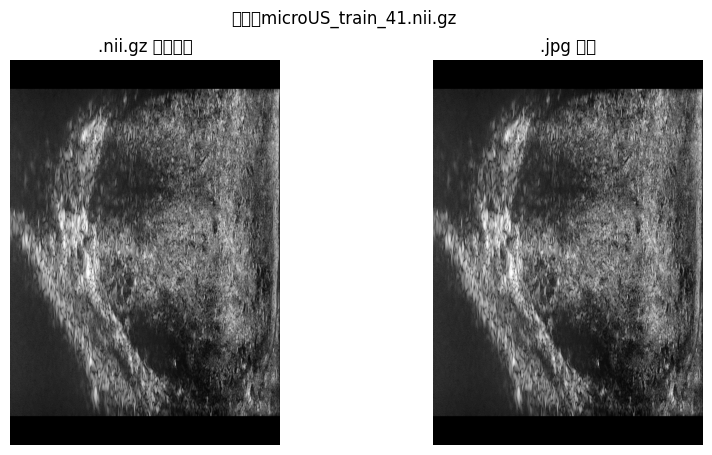

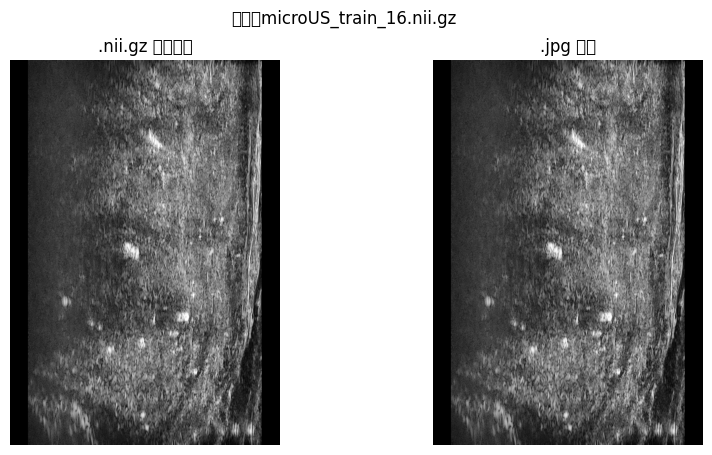

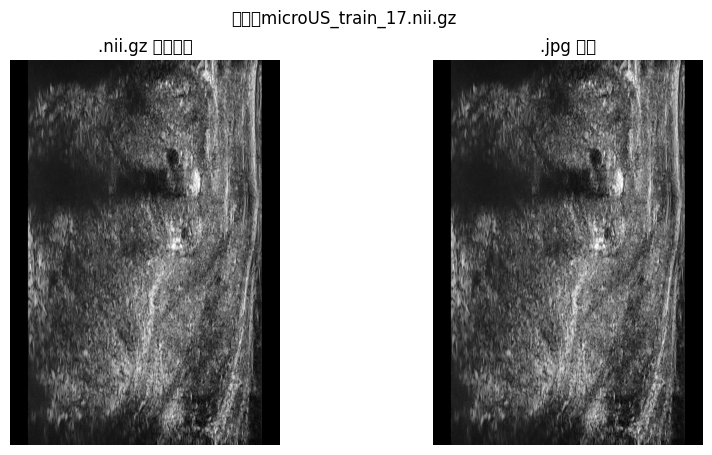

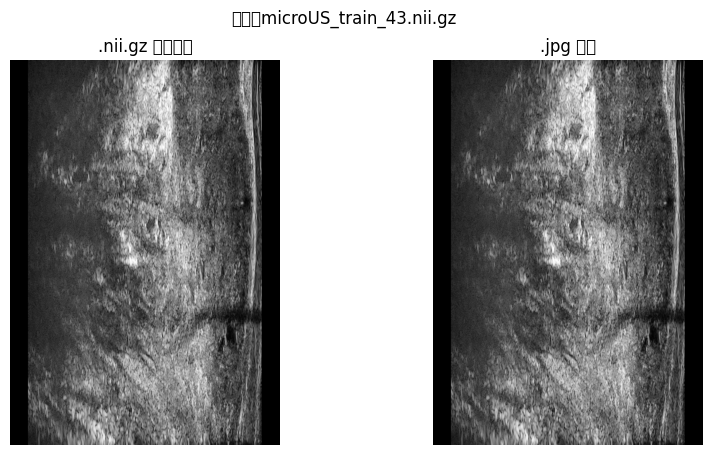

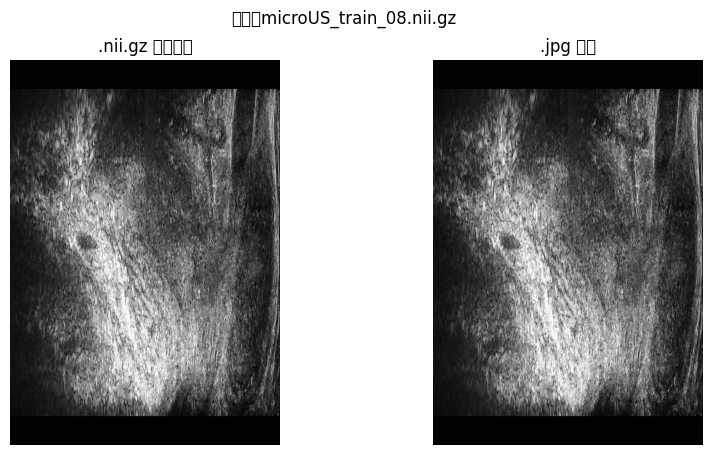

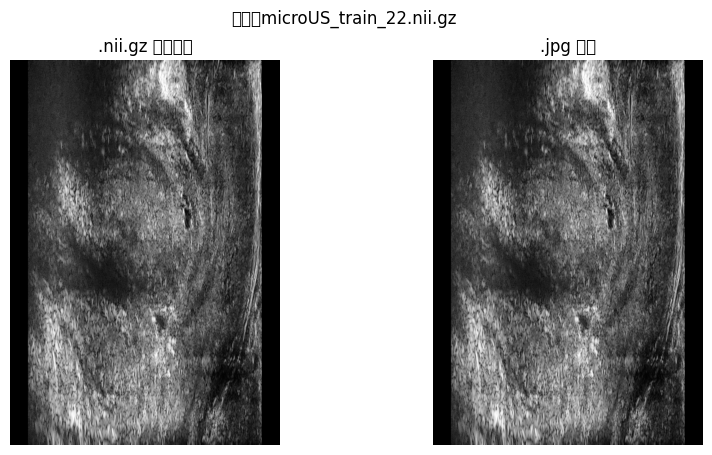

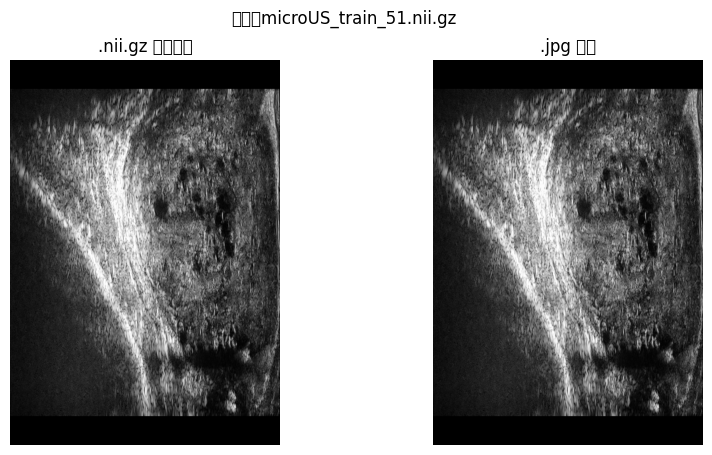

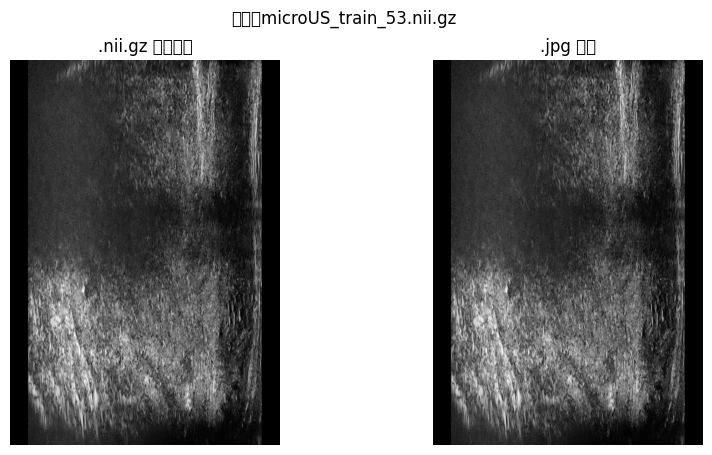

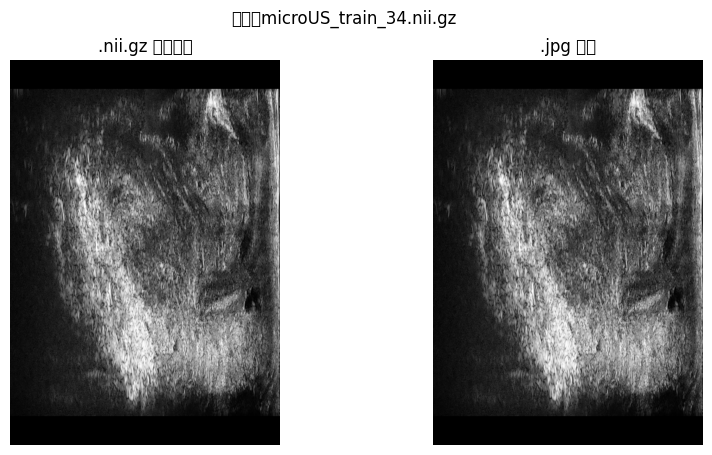

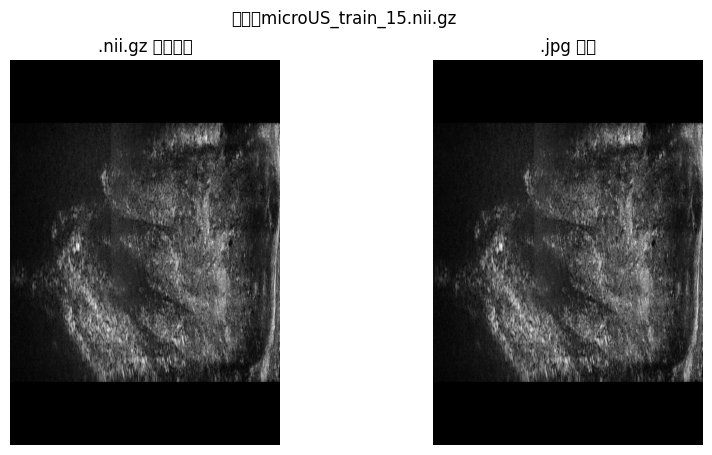

In [4]:

# 随机选择 10 个文件进行对比
sample_files = random.sample(nii_files, min(10, len(nii_files)))

for sample_file in sample_files:
    # 加载 .nii.gz 文件
    nii_path = os.path.join(input_dir, sample_file)
    nii_data = nib.load(nii_path)
    image_data = nii_data.get_fdata()

    # 获取中间切片
    mid_slice = image_data.shape[2] // 2
    slice_data = image_data[:, :, mid_slice]

    # 归一化到 0-255 范围
    slice_data = cv2.normalize(slice_data, None, 0, 255, cv2.NORM_MINMAX)
    slice_data = slice_data.astype(np.uint8)

    # 加载对应的 .jpg 文件
    jpg_filename = sample_file.replace('.nii.gz', '.jpg')
    jpg_path = os.path.join(output_dir, jpg_filename)
    jpg_image = cv2.imread(jpg_path, cv2.IMREAD_GRAYSCALE)

    # 显示对比
    plt.figure(figsize=(10, 5))
    plt.suptitle(f"对比：{sample_file}")

    plt.subplot(1, 2, 1)
    plt.title('.nii.gz 中间切片')
    plt.imshow(slice_data, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title('.jpg 图像')
    plt.imshow(jpg_image, cmap='gray')
    plt.axis('off')

    plt.show()